# **Dependencies**

In [2]:
!pip install -q kagglehub pyspark

# **Imports**

In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
from pyspark.sql import SparkSession

In [6]:
import kagglehub
import os
import glob
import shutil

In [26]:
from pyspark.sql.functions import col, sum

In [14]:
from pyspark.sql.functions import unix_timestamp

In [21]:
from pyspark.sql.functions import abs


In [28]:
from pyspark.sql.functions import when, count


In [30]:
from pyspark.sql.types import *

In [62]:
from functools import reduce


In [140]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pyspark.sql import functions as F
import matplotlib.gridspec as gridspec
import numpy as np
import time

# **Load and merge data**

In [5]:
spark = (SparkSession.builder.appName("Taxi2020").getOrCreate())
print(spark.version)

4.0.2


In [7]:
path=kagglehub.dataset_download("marcbrandner/tlc-trip-record-data-yellow-taxi")

100%|██████████| 27.5G/27.5G [04:57<00:00, 99.1MB/s]

Extracting files...


In [8]:
files_2020=sorted(
    glob.glob(
        os.path.join(path, "yellow_tripdata_2020-*.parquet")
    )
)
print("Files found:")
for f in files_2020:
  print(os.path.basename(f))

Files found:
yellow_tripdata_2020-01.parquet
yellow_tripdata_2020-02.parquet
yellow_tripdata_2020-03.parquet
yellow_tripdata_2020-04.parquet
yellow_tripdata_2020-05.parquet
yellow_tripdata_2020-06.parquet
yellow_tripdata_2020-07.parquet
yellow_tripdata_2020-08.parquet
yellow_tripdata_2020-09.parquet
yellow_tripdata_2020-10.parquet
yellow_tripdata_2020-11.parquet
yellow_tripdata_2020-12.parquet


# **Data Cleaning**

In [63]:
dfs = []
for f in files_2020:
    dfs.append(spark.read.parquet(f))

df = reduce(
    lambda a, b: a.unionByName(b, allowMissingColumns=True),
    dfs
)

In [64]:
df = (
    df
    .withColumn("VendorID", col("VendorID").cast("long"))
    .withColumn("passenger_count", col("passenger_count").cast("long"))
    .withColumn("RatecodeID", col("RatecodeID").cast("long"))
    .withColumn("PULocationID", col("PULocationID").cast("long"))
    .withColumn("DOLocationID", col("DOLocationID").cast("long"))
    .withColumn("payment_type", col("payment_type").cast("long"))
    .withColumn("airport_fee", col("airport_fee").cast("double"))
)

In [65]:
df.printSchema()

root
 |-- VendorID: long (nullable = true)
 |-- tpep_pickup_datetime: timestamp_ntz (nullable = true)
 |-- tpep_dropoff_datetime: timestamp_ntz (nullable = true)
 |-- passenger_count: long (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: long (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: long (nullable = true)
 |-- DOLocationID: long (nullable = true)
 |-- payment_type: long (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- airport_fee: double (nullable = true)



In [66]:
df.show(5)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       1| 2020-01-01 00:28:15|  2020-01-01 00:33:03|              1|          1.2|         1|                 N|         238|         239|           1|        6.0|  3.0|    0.5|      1.4

In [67]:
df.count()

24649092

## **Missings**

In [ ]:
df.select([
    count(when(col(c).isNull(), c)).alias(c)
    for c in df.columns
]).show()

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+
|       0|                   0|                    0|         809967|            0|    809967|            809967|           0|           0|           0|          0|    0|      0|         

In [69]:
df = df.drop("airport_fee")

In [70]:
df = df.dropna()

## **Inconsistencies**

**Data Type Standardization**

Some columns contained inconsistent data types.

Categorical and identifier fields stored as floating-point values were converted to integer types to ensure schema consistency and improve data quality.

In [71]:
int_cols = [
    "VendorID",
    "PULocationID",
    "DOLocationID",
    "payment_type"
]

for c in int_cols:
    df = df.withColumn(c, col(c).cast("int"))

**Invalid Temporal Data**

A temporal consistency check was performed on the trip records.

A total of 181 records were identified where the drop-off timestamp occurred before the pickup timestamp, indicating invalid trip durations and potential data entry or system recording errors.


In [72]:
df.filter(
    col("tpep_dropoff_datetime") < col("tpep_pickup_datetime")
).count()

181

In [73]:
df.filter(
    col("tpep_dropoff_datetime") < col("tpep_pickup_datetime")
).show(5, truncate=False)

+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+
|1       |2020-01-04 08:19:55 |2020-01-02 10:09:33  |1              |3.5          |1         |N                 |107         |237         |1           |16.5       |2.5  |0.5    |4.95      |0.0         |0.3                  

In [74]:
df = df.filter(
    col("tpep_dropoff_datetime") >= col("tpep_pickup_datetime")
)

**Trip Duration Anomaly Detection**

A total of 54 records were identified with trip durations exceeding 24 hours. These cases are considered anomalous, as taxi trips of such length are highly unlikely under normal operating conditions and likely indicate data recording or system errors.

In [75]:
df = df.withColumn(
    "trip_duration_minutes",
    (
        unix_timestamp("tpep_dropoff_datetime")
        - unix_timestamp("tpep_pickup_datetime")
    ) / 60
)

df.filter(col("trip_duration_minutes") > 1440).count()

54

In [79]:
df = df.filter(
    (col("trip_duration_minutes") >= 0) &
    (col("trip_duration_minutes") <= 1440)
)

**Distance Anomalies**

A validation of trip distance values revealed a significant number of inconsistencies. A total of 317585 records were identified where the trip distance was less than or equal to zero.

Such values are not realistic in the context of taxi trip. These records were considered invalid for further analysis.

In [80]:
df.filter(col("trip_distance") <= 0).count()

317585

In [81]:
df=df.filter(col("trip_distance")>0)

**Passenger Count Problems**

Passenger count validation revealed multiple inconsistencies. A total of 480324 records contained non-positive values, while 25 records reported more than 8 passengers, exceeding the typical capacity of a standard taxi vehicle.


In [82]:
df.filter(col("passenger_count") <= 0).count()

480324

In [83]:
df.filter(col("passenger_count") > 8).count()

25

In [84]:
df = df.filter(
    (col("passenger_count") > 0) &
    (col("passenger_count") <= 8)
)

**Payment Inconsistencies**

An analysis of fare amounts identified 82045 records with negative values, which are not valid in a standard fare structure.

A fare consistency check was performed by comparing the recorded total amount with the sum of individual fare components.

A total of 6783902 records showed discrepancies greater than 1 monetary unit between the computed and recorded total values. This suggests inconsistencies in fare aggregation or missing components in the dataset.

In [87]:
df.filter(col("fare_amount") < 0).count()

82045

In [89]:
df = df.filter(col("fare_amount") >= 0)

In [90]:
df_check = df.withColumn(
    "calculated_total",
    col("fare_amount")
    + col("extra")
    + col("mta_tax")
    + col("tip_amount")
    + col("tolls_amount")
    + col("improvement_surcharge")
    + col("congestion_surcharge")
)

df_inconsistent = df_check.filter(
    abs(col("calculated_total") - col("total_amount")) > 1
)

df_inconsistent.count()

6783902

In [91]:
df = df.filter(
    abs(
        (col("fare_amount")
        + col("extra")
        + col("mta_tax")
        + col("tip_amount")
        + col("tolls_amount")
        + col("improvement_surcharge")
        + col("congestion_surcharge"))
        - col("total_amount")
    ) <= 1
)

**Duplicates**

In [93]:
duplicates_count = df.count() - df.dropDuplicates().count()
print(duplicates_count)

0


In [94]:
df.count()

16175009

After data cleaning and removal of missing values and inconsistencies, the final dataset contains 16,175,009 records.

## **Outliers**

In [96]:
num_cols = [
    "passenger_count",
    "trip_distance",
    "fare_amount",
    "extra",
    "mta_tax",
    "tip_amount",
    "tolls_amount",
    "improvement_surcharge",
    "total_amount",
    "congestion_surcharge",
]

In [97]:
df.select(num_cols).describe().show()

+-------+------------------+-----------------+------------------+-------------------+--------------------+------------------+------------------+---------------------+------------------+--------------------+
|summary|   passenger_count|    trip_distance|       fare_amount|              extra|             mta_tax|        tip_amount|      tolls_amount|improvement_surcharge|      total_amount|congestion_surcharge|
+-------+------------------+-----------------+------------------+-------------------+--------------------+------------------+------------------+---------------------+------------------+--------------------+
|  count|          16175009|         16175009|          16175009|           16175009|            16175009|          16175009|          16175009|             16175009|          16175009|            16175009|
|   mean|1.6079803726848003| 2.92322542015256|12.361708017596799| 0.3216008405312206| 0.49775991098366623|2.1268990978631153|0.2906670289959191|  0.29987402790211076|18.129

In [111]:
def plot_top_categories(pdf, column, color, top_n=20):
    counts = pdf[column].value_counts().nlargest(top_n)

    plt.figure(figsize=(10, 4))
    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values,
        color=color
    )

    plt.title(f"Top {top_n} categories: {column}", fontweight='bold')
    plt.xlabel(column)
    plt.ylabel("Count")
    plt.xticks(rotation=45)
    plt.show()

In [114]:
num_cols = [
    ("trip_distance", "coral", 0, 20),
    ("fare_amount", "mediumseagreen", 0, 80),
    ("tip_amount", "gold", 0, 15),
    ("total_amount", "orchid", 0, 100)
]

small_cat_cols = [
    ("VendorID", "skyblue"),
    ("RatecodeID", "lightgreen"),
    ("payment_type", "salmon"),
    ("store_and_fwd_flag", "orange"),
]

In [115]:
SAMPLE_FRACTION = 0.005

sample_cols = (
    [c[0] for c in num_cols] +
    [c[0] for c in small_cat_cols]
)

pdf = (
    df.select(*sample_cols)
      .sample(False, SAMPLE_FRACTION, seed=42)
      .toPandas()
)

print(f"Sample size: {len(pdf):,}")

Sample size: 81,233


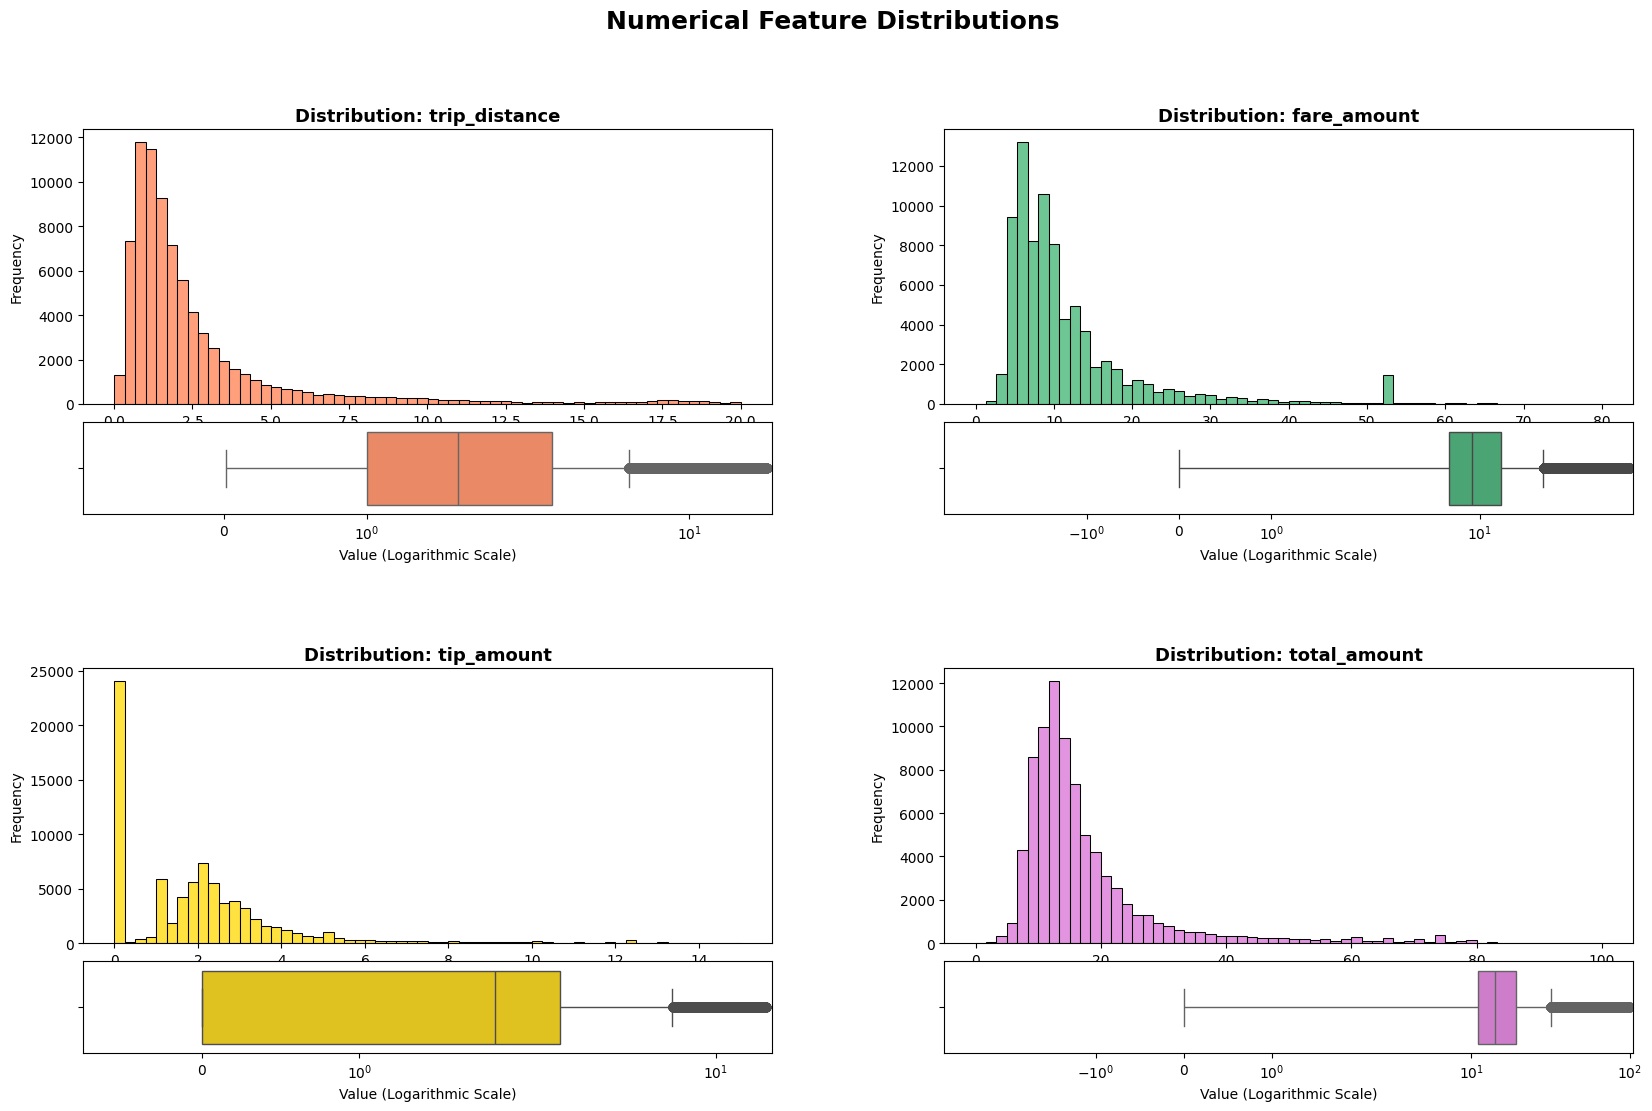

In [116]:
fig_num = plt.figure(figsize=(20, 12))

gs_num = gridspec.GridSpec(
    2, 2,
    figure=fig_num,
    hspace=0.4,
    wspace=0.25
)

for i, (column, color, v_min, v_max) in enumerate(num_cols):

    # Filter value range
    data = pdf[
        (pdf[column] >= v_min) &
        (pdf[column] <= v_max)
    ][column].dropna()

    # Inner grid
    inner_gs = gridspec.GridSpecFromSubplotSpec(
        2, 1,
        subplot_spec=gs_num[i],
        height_ratios=[3, 1],
        hspace=0.1
    )

    ax_hist = fig_num.add_subplot(inner_gs[0])
    ax_box = fig_num.add_subplot(inner_gs[1])

    # Histogram
    sns.histplot(
        data,
        bins=60,
        color=color,
        edgecolor='black',
        ax=ax_hist
    )

    ax_hist.set_title(
        f"Distribution: {column}",
        fontweight='bold',
        fontsize=13
    )

    ax_hist.set_xlabel(column)
    ax_hist.set_ylabel("Frequency")

    # Boxplot
    sns.boxplot(
        x=data,
        color=color,
        ax=ax_box
    )

    ax_box.set_xscale('symlog')

    ax_box.set_xlabel(
        "Value (Logarithmic Scale)"
    )

plt.suptitle(
    "Numerical Feature Distributions",
    fontsize=18,
    fontweight='bold'
)

plt.show()

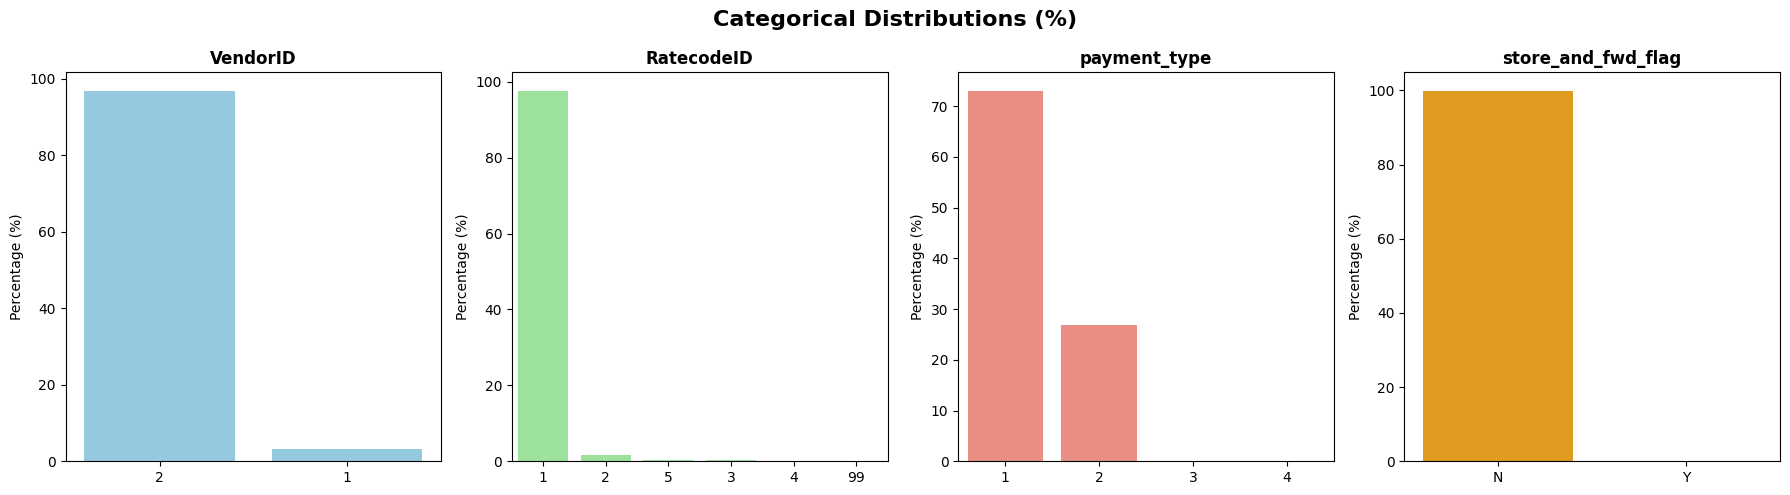

In [118]:
fig, axes = plt.subplots(1, len(small_cat_cols), figsize=(18,5))

for ax, (col_name, color) in zip(axes, small_cat_cols):

    if col_name not in pdf.columns:
        ax.set_title(f"{col_name} missing")
        ax.axis("off")
        continue

    # percentagem em vez de count
    counts = pdf[col_name].value_counts(normalize=True) * 100

    sns.barplot(
        x=counts.index.astype(str),
        y=counts.values,
        color=color,
        ax=ax
    )

    ax.set_title(col_name, fontweight='bold')
    ax.set_ylabel("Percentage (%)")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=0)

plt.suptitle("Categorical Distributions (%)", fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# **Efficiency and Operations**

**Efficiency vs. Demand: Hourly Analysis of Taxi Operations**

In [137]:
df_speed = df.withColumn(
    "duration_min",
    (F.unix_timestamp("tpep_dropoff_datetime") - F.unix_timestamp("tpep_pickup_datetime")) / 60
).withColumn(
    "hour", F.hour("tpep_pickup_datetime")
).withColumn(
    "day_phase",
    F.when((F.col("hour") >= 0) & (F.col("hour") < 6), "Night")
     .when((F.col("hour") >= 6) & (F.col("hour") < 11), "Morning Peak")
     .when((F.col("hour") >= 11) & (F.col("hour") < 16), "Afternoon")
     .otherwise("Evening Peak")
).filter(
    (F.col("duration_min") > 0) & (F.col("trip_distance") > 0)
)

In [141]:
df_speed.createOrReplaceTempView("taxi_data")
df_speed.unpersist()

#pyspark
start_pyspark = time.time()
df_pyspark = df_speed.groupBy("hour", "day_phase").agg(
    F.count("*").alias("trip_count"),
    F.avg(F.col("trip_distance") / (F.col("duration_min") / 60)).alias("avg_speed"),
    F.avg("total_amount").alias("avg_total")
).orderBy("hour")
count_py = df_pyspark.count()
duration_pyspark = time.time() - start_pyspark

#sparksql
start_sql = time.time()
df_sql = spark.sql("""
    SELECT
        hour,
        day_phase,
        COUNT(*) AS trip_count,
        AVG(trip_distance / (duration_min / 60)) AS avg_speed,
        AVG(total_amount) AS avg_total
    FROM taxi_data
    GROUP BY hour, day_phase
    ORDER BY hour
""")

count_sql = df_sql.count()
duration_sql = time.time() - start_sql

print(f"PySpark execution time: {duration_pyspark:.4f}s")
print(f"SQL execution time: {duration_sql:.4f}s")

PySpark execution time: 22.7789s
SQL execution time: 18.7681s


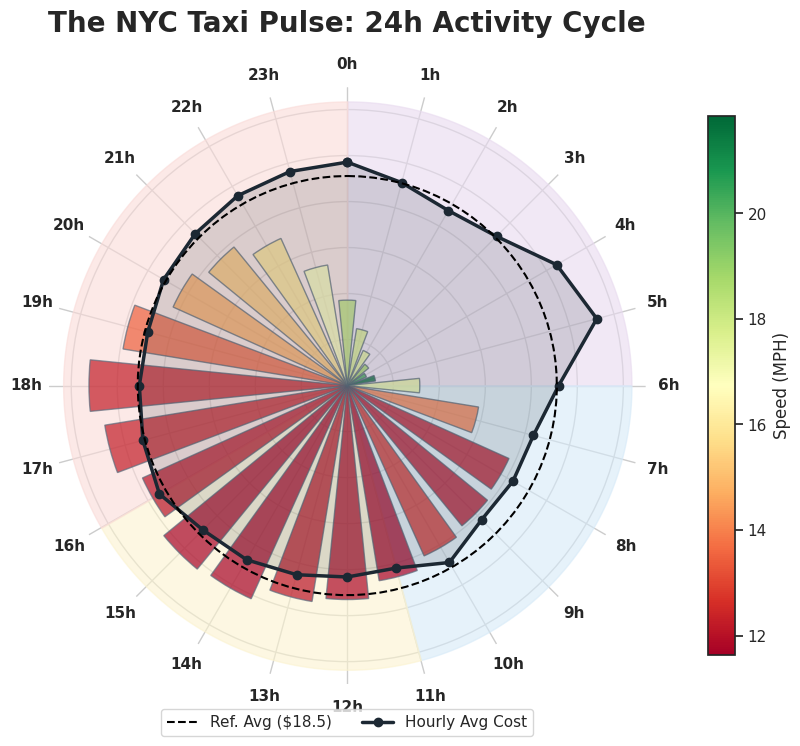

In [196]:
df_plot = df_pyspark.toPandas()

labels = df_plot['hour'].values
counts = df_plot['trip_count'].values
speeds = df_plot['avg_speed'].values
totals = df_plot['avg_total'].values

#cycle
angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles_closed = angles + [angles[0]]
totals_closed = np.append(totals, totals[0])
reference_val = 18.50
scale_factor = counts.max() / totals.max()
ref_scaled = reference_val * scale_factor
totals_scaled = totals_closed * scale_factor

fig, ax = plt.subplots(figsize=(10, 10), subplot_kw={'projection': 'polar'}, facecolor='white')
phases = [(0, 6, "#E8DAEF"), (6, 11, "#D6EAF8"), (11, 16, "#FCF3CF"), (16, 24, "#FADBD8")]
for s, e, c in phases:
    ax.fill_between(np.linspace((s/24)*2*np.pi, (e/24)*2*np.pi, 100), 0, counts.max()*1.1, color=c, alpha=0.6, zorder=1)

norm = plt.Normalize(speeds.min(), speeds.max())
ax.bar(angles, counts, width=0.2, color=plt.cm.RdYlGn(norm(speeds)), alpha=0.7, edgecolor='#5D6D7E', zorder=2)
ax.plot(np.linspace(0, 2*np.pi, 100), [ref_scaled]*100, color='black', linestyle='--', linewidth=1.5, label=f'Ref. Avg (${reference_val})', zorder=5)
ax.fill(angles_closed, totals_scaled, color='#1C2833', alpha=0.15, zorder=3)
ax.plot(angles_closed, totals_scaled, color='#1C2833', linewidth=2.5, marker='o', label='Hourly Avg Cost', zorder=4)
ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_xticks(np.linspace(0, 2 * np.pi, 24, endpoint=False))
ax.set_xticklabels([f"{h}h" for h in range(24)], fontweight='bold')
ax.set_yticklabels([])
ax.spines['polar'].set_visible(False)

sm = plt.cm.ScalarMappable(cmap=plt.cm.RdYlGn, norm=norm)
plt.colorbar(sm, ax=ax, orientation='vertical', pad=0.08, shrink=0.7).set_label('Speed (MPH)')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=True)

plt.title('The NYC Taxi Pulse: 24h Activity Cycle', fontsize=20, fontweight='bold', pad=40)
plt.show()

**Revenue Leakage: Analysis of Non-Revenue Trips and Disputed Payments**

This visualization provides a critical audit of the taxi system's operational efficiency by mapping Revenue Leakage across distinct day phases. By isolating anomalies, specifically payment disputes, technical 'zero-fare' errors, and non-charged trips, the chart identifies significant financial friction within the payment cycle. A primary observation is the staggering impact of 'No Charge' status during the Morning Peak, accounting for over $1.2 million in lost potential revenue.

Furthermore, the rising trend in Disputed Transactions during the Evening Peak suggests increased operational stress or billing conflicts during high-traffic hours. These insights are vital for stakeholders to prioritize system calibrations and fraud prevention measures, shifting focus from general oversight to targeted financial recovery in high-loss periods.

In [157]:
#pyspark
start_py = time.time()
df_dw_py = df_speed.filter("(fare_amount <= 0 AND trip_distance > 0) OR payment_type IN (3, 4)") \
    .groupBy("day_phase", "payment_type") \
    .agg(
        F.count("*").alias("trips"),
        F.sum("trip_distance").alias("miles"),
        F.abs(F.sum("total_amount")).alias("loss")
    )
duration_py = time.time() - start_py

#sparksql
start_sql = time.time()
df_dw_sql = spark.sql("""
    SELECT day_phase,
           CASE payment_type
                WHEN 3 THEN 'No Charge'
                WHEN 4 THEN 'Dispute'
                ELSE 'Zero Fare / Tech Error'
           END as category,
           COUNT(*) as trips,
           SUM(trip_distance) as miles,
           ABS(SUM(total_amount)) as loss
    FROM taxi_data
    WHERE (fare_amount <= 0 AND trip_distance > 0) OR payment_type IN (3, 4)
    GROUP BY 1, 2
""")
duration_sql = time.time() - start_sql

print(f"PySpark: {duration_py:.4f}s | SQL: {duration_sql:.4f}s")

PySpark: 0.0537s | SQL: 0.0248s


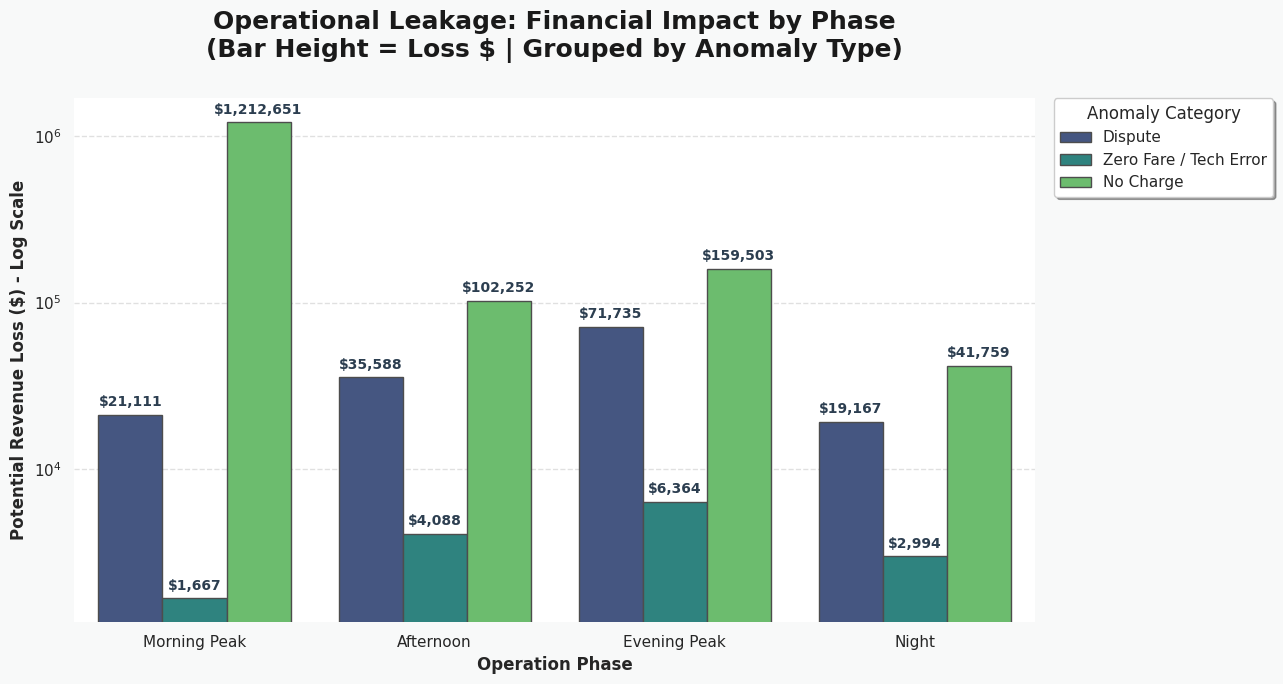

In [189]:
pdf_dw = df_dw_sql.toPandas()

order = ['Morning Peak', 'Afternoon', 'Evening Peak', 'Night']
pdf_dw['day_phase'] = pd.Categorical(pdf_dw['day_phase'], categories=order, ordered=True)
pdf_dw = pdf_dw.sort_values('day_phase')

plt.figure(figsize=(13, 7), facecolor='#F8F9F9')
ax = plt.gca()
sns.barplot(
    data=pdf_dw,
    x='day_phase',
    y='loss',
    hue='category',
    palette='viridis',
    edgecolor='0.3',
    linewidth=1,
    ax=ax
)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'${p.get_height():,.0f}',
                        (p.get_x() + p.get_width() / 2., p.get_height()),
                        ha = 'center', va = 'center',
                        xytext = (0, 9),
                        textcoords = 'offset points',
                        fontsize=10, fontweight='bold', color='#2C3E50')

ax.set_yscale('log')
plt.title("Operational Leakage: Financial Impact by Phase\n(Bar Height = Loss $ | Grouped by Anomaly Type)",
          fontsize=18, fontweight='bold', pad=30, color='#1A1A1A')
plt.ylabel("Potential Revenue Loss ($) - Log Scale", fontsize=12, fontweight='bold')
plt.xlabel("Operation Phase", fontsize=12, fontweight='bold')

sns.despine(left=True, bottom=True)
ax.yaxis.grid(True, linestyle='--', alpha=0.6)
plt.legend(
    title="Anomaly Category",
    frameon=True,
    shadow=True,
    loc='upper left',
    bbox_to_anchor=(1.02, 1),
    borderaxespad=0
)

plt.tight_layout()
plt.show()

**Operational Efficiency Analysis: The Inverse Relationship Between Revenue Density and Traffic Velocity**

This dual-axis visualization investigates the core operational efficiency of the taxi fleet by correlating Revenue per Mile (RPM) with Average Speed (MPH) across a 24-hour cycle. The analysis reveals a critical 'Efficiency Paradox': while revenue density typically peaks during the Evening Rush, operational friction (traffic congestion) causes a significant drop in velocity, potentially increasing vehicle wear and driver fatigue. By highlighting these 'Golden Hours' versus 'High-Friction Periods,' this chart provides stakeholders with the data necessary to evaluate the effectiveness of current surcharges and identifies specific windows—such as the early morning—where high speed and stable revenue offer the highest net profitability per hour.

In [169]:
#sparksql
start_sql = time.time()
df_efficiency_sql = spark.sql("""
    SELECT
        hour,
        -- Rentabilidade: Quanto ganhamos por cada milha percorrida
        ROUND(AVG(total_amount / trip_distance), 2) AS rev_per_mile,
        -- Esforço: Velocidade média (Milhas / Horas)
        ROUND(AVG(trip_distance / (duration_min / 60)), 2) AS avg_speed_mph,
        COUNT(*) as trip_volume
    FROM taxi_data
    WHERE trip_distance > 0 AND duration_min > 0 AND total_amount > 0
    GROUP BY hour
    ORDER BY hour
""")
pdf_efficiency = df_efficiency_sql.toPandas()
duration_sql = time.time() - start_sql

#pyspark
start_py = time.time()
df_efficiency_py = df_speed.filter("trip_distance > 0 AND duration_min > 0 AND total_amount > 0") \
    .groupBy("hour") \
    .agg(
        F.round(F.avg(F.col("total_amount") / F.col("trip_distance")), 2).alias("rev_per_mile"),
        F.round(F.avg(F.col("trip_distance") / (F.col("duration_min") / 60)), 2).alias("avg_speed_mph")
    ).orderBy("hour")
duration_py = time.time() - start_py

print(f"SparkSQL: {duration_sql:.4f}s | PySpark: {duration_py:.4f}s")

SparkSQL: 19.8549s | PySpark: 0.0465s


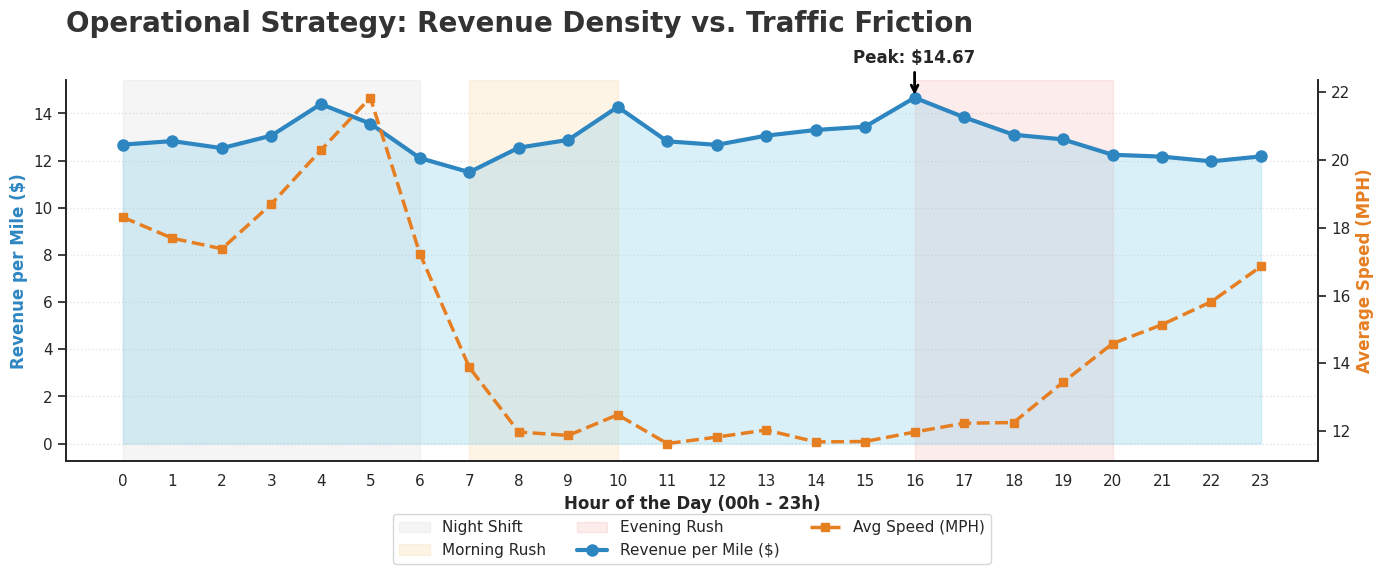

In [186]:
fig, ax1 = plt.subplots(figsize=(14, 6), facecolor='white')
ax2 = ax1.twinx()

ax1.axvspan(0, 6, color='gray', alpha=0.08, label='Night Shift')
ax1.axvspan(7, 10, color='#F39C12', alpha=0.1, label='Morning Rush')
ax1.axvspan(16, 20, color='#E74C3C', alpha=0.1, label='Evening Rush')

line1, = ax1.plot(pdf_efficiency['hour'], pdf_efficiency['rev_per_mile'],
                  color='#2E86C1', marker='o', linewidth=3, markersize=8,
                  label='Revenue per Mile ($)')
ax1.fill_between(pdf_efficiency['hour'], pdf_efficiency['rev_per_mile'],
                 color='skyblue', alpha=0.3)
line2, = ax2.plot(pdf_efficiency['hour'], pdf_efficiency['avg_speed_mph'],
                  color='#E67E22', linestyle='--', linewidth=2.5, marker='s', markersize=6,
                  label='Avg Speed (MPH)')
ax1.set_title("Operational Strategy: Revenue Density vs. Traffic Friction",
             fontsize=20, fontweight='bold', pad=35, loc='left', color='#333333')
ax1.set_xlabel("Hour of the Day (00h - 23h)", fontsize=12, fontweight='bold')
ax1.set_ylabel("Revenue per Mile ($)", fontsize=12, fontweight='bold', color='#2E86C1')
ax2.set_ylabel("Average Speed (MPH)", fontsize=12, fontweight='bold', color='#E67E22')
ax1.set_xticks(range(0, 24))
ax1.grid(axis='y', linestyle=':', alpha=0.5)

lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines + lines2, labels + labels2,
           loc='upper center',
           bbox_to_anchor=(0.5, -0.12),
           ncol=3,
           frameon=True,
           fontsize=11)

max_rev_hour = pdf_efficiency.loc[pdf_efficiency['rev_per_mile'].idxmax(), 'hour']
max_rev_val = pdf_efficiency['rev_per_mile'].max()
ax1.annotate(f'Peak: ${max_rev_val}',
             xy=(max_rev_hour, max_rev_val),
             xytext=(max_rev_hour, max_rev_val + 1.5),
             ha='center',
             arrowprops=dict(arrowstyle='->', lw=2, color='black'),
             fontsize=12, fontweight='bold')

ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
plt.show()

**Logistics Performance: Fleet Idle Time and Deadheading Friction Analysis**

In [184]:
df_logistica = df.select(
    "VendorID",
    "tpep_pickup_datetime",
    "tpep_dropoff_datetime",
    "PULocationID"
)

#pyspark
start_py = time.time()

window_spec = Window.partitionBy("VendorID").orderBy("tpep_pickup_datetime")
df_idle_py = df_logistica.withColumn("prev_dropoff", F.lag("tpep_dropoff_datetime").over(window_spec)) \
    .withColumn("idle_time_min",
                (F.unix_timestamp("tpep_pickup_datetime") - F.unix_timestamp("prev_dropoff")) / 60) \
    .filter("prev_dropoff IS NOT NULL AND idle_time_min > 0 AND idle_time_min < 60") \
    .groupBy("PULocationID") \
    .agg(F.avg("idle_time_min").alias("avg_idle_minutes")) \
    .orderBy(F.desc("avg_idle_minutes")) \
    .limit(5)

pdf_idle = df_idle_py.toPandas()
duration_py = time.time() - start_py

#sparksql
df_logistica.createOrReplaceTempView("taxi_logistics_data")

start_sql = time.time()
df_idle_sql = spark.sql("""
    WITH TripSequencing AS (
        SELECT
            PULocationID,
            tpep_pickup_datetime,
            LAG(tpep_dropoff_datetime) OVER (PARTITION BY VendorID ORDER BY tpep_pickup_datetime) as prev_dropoff
        FROM taxi_logistics_data
    )
    SELECT
        PULocationID,
        ROUND(AVG(UNIX_TIMESTAMP(tpep_pickup_datetime) - UNIX_TIMESTAMP(prev_dropoff)) / 60, 2) as avg_idle_minutes
    FROM TripSequencing
    WHERE prev_dropoff IS NOT NULL
      AND (UNIX_TIMESTAMP(tpep_pickup_datetime) - UNIX_TIMESTAMP(prev_dropoff)) / 60 BETWEEN 0.1 AND 60
    GROUP BY PULocationID
    ORDER BY avg_idle_minutes DESC
    LIMIT 5
""")
pdf_idle_sql = df_idle_sql.toPandas()
duration_sql = time.time() - start_sql

print(f"SparkSQL: {duration_sql:.4f}s | PySpark: {duration_py:.4f}s")

SparkSQL: 98.4171s | PySpark: 78.5409s


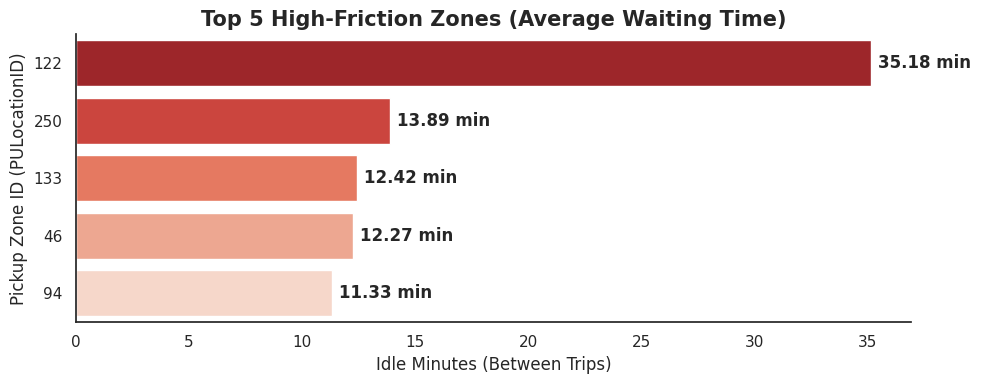

In [183]:
plt.figure(figsize=(10, 4))
colors = sns.color_palette("Reds_r", n_colors=5)
ax = sns.barplot(
    x="avg_idle_minutes",
    y=pdf_idle_sql["PULocationID"].astype(str),
    data=pdf_idle_sql,
    palette=colors,
    hue=pdf_idle_sql["PULocationID"].astype(str),
    legend=False
)

plt.title("Top 5 High-Friction Zones (Average Waiting Time)", fontsize=15, fontweight='bold')
plt.xlabel("Idle Minutes (Between Trips)", fontsize=12)
plt.ylabel("Pickup Zone ID (PULocationID)", fontsize=12)

for p in ax.patches:
    ax.annotate(f'{p.get_width():.2f} min',
                (p.get_width(), p.get_y() + p.get_height() / 2),
                xytext=(5, 0), textcoords='offset points',
                va='center', fontweight='bold')

sns.despine()
plt.tight_layout()
plt.show()

# **Final Dashboard**

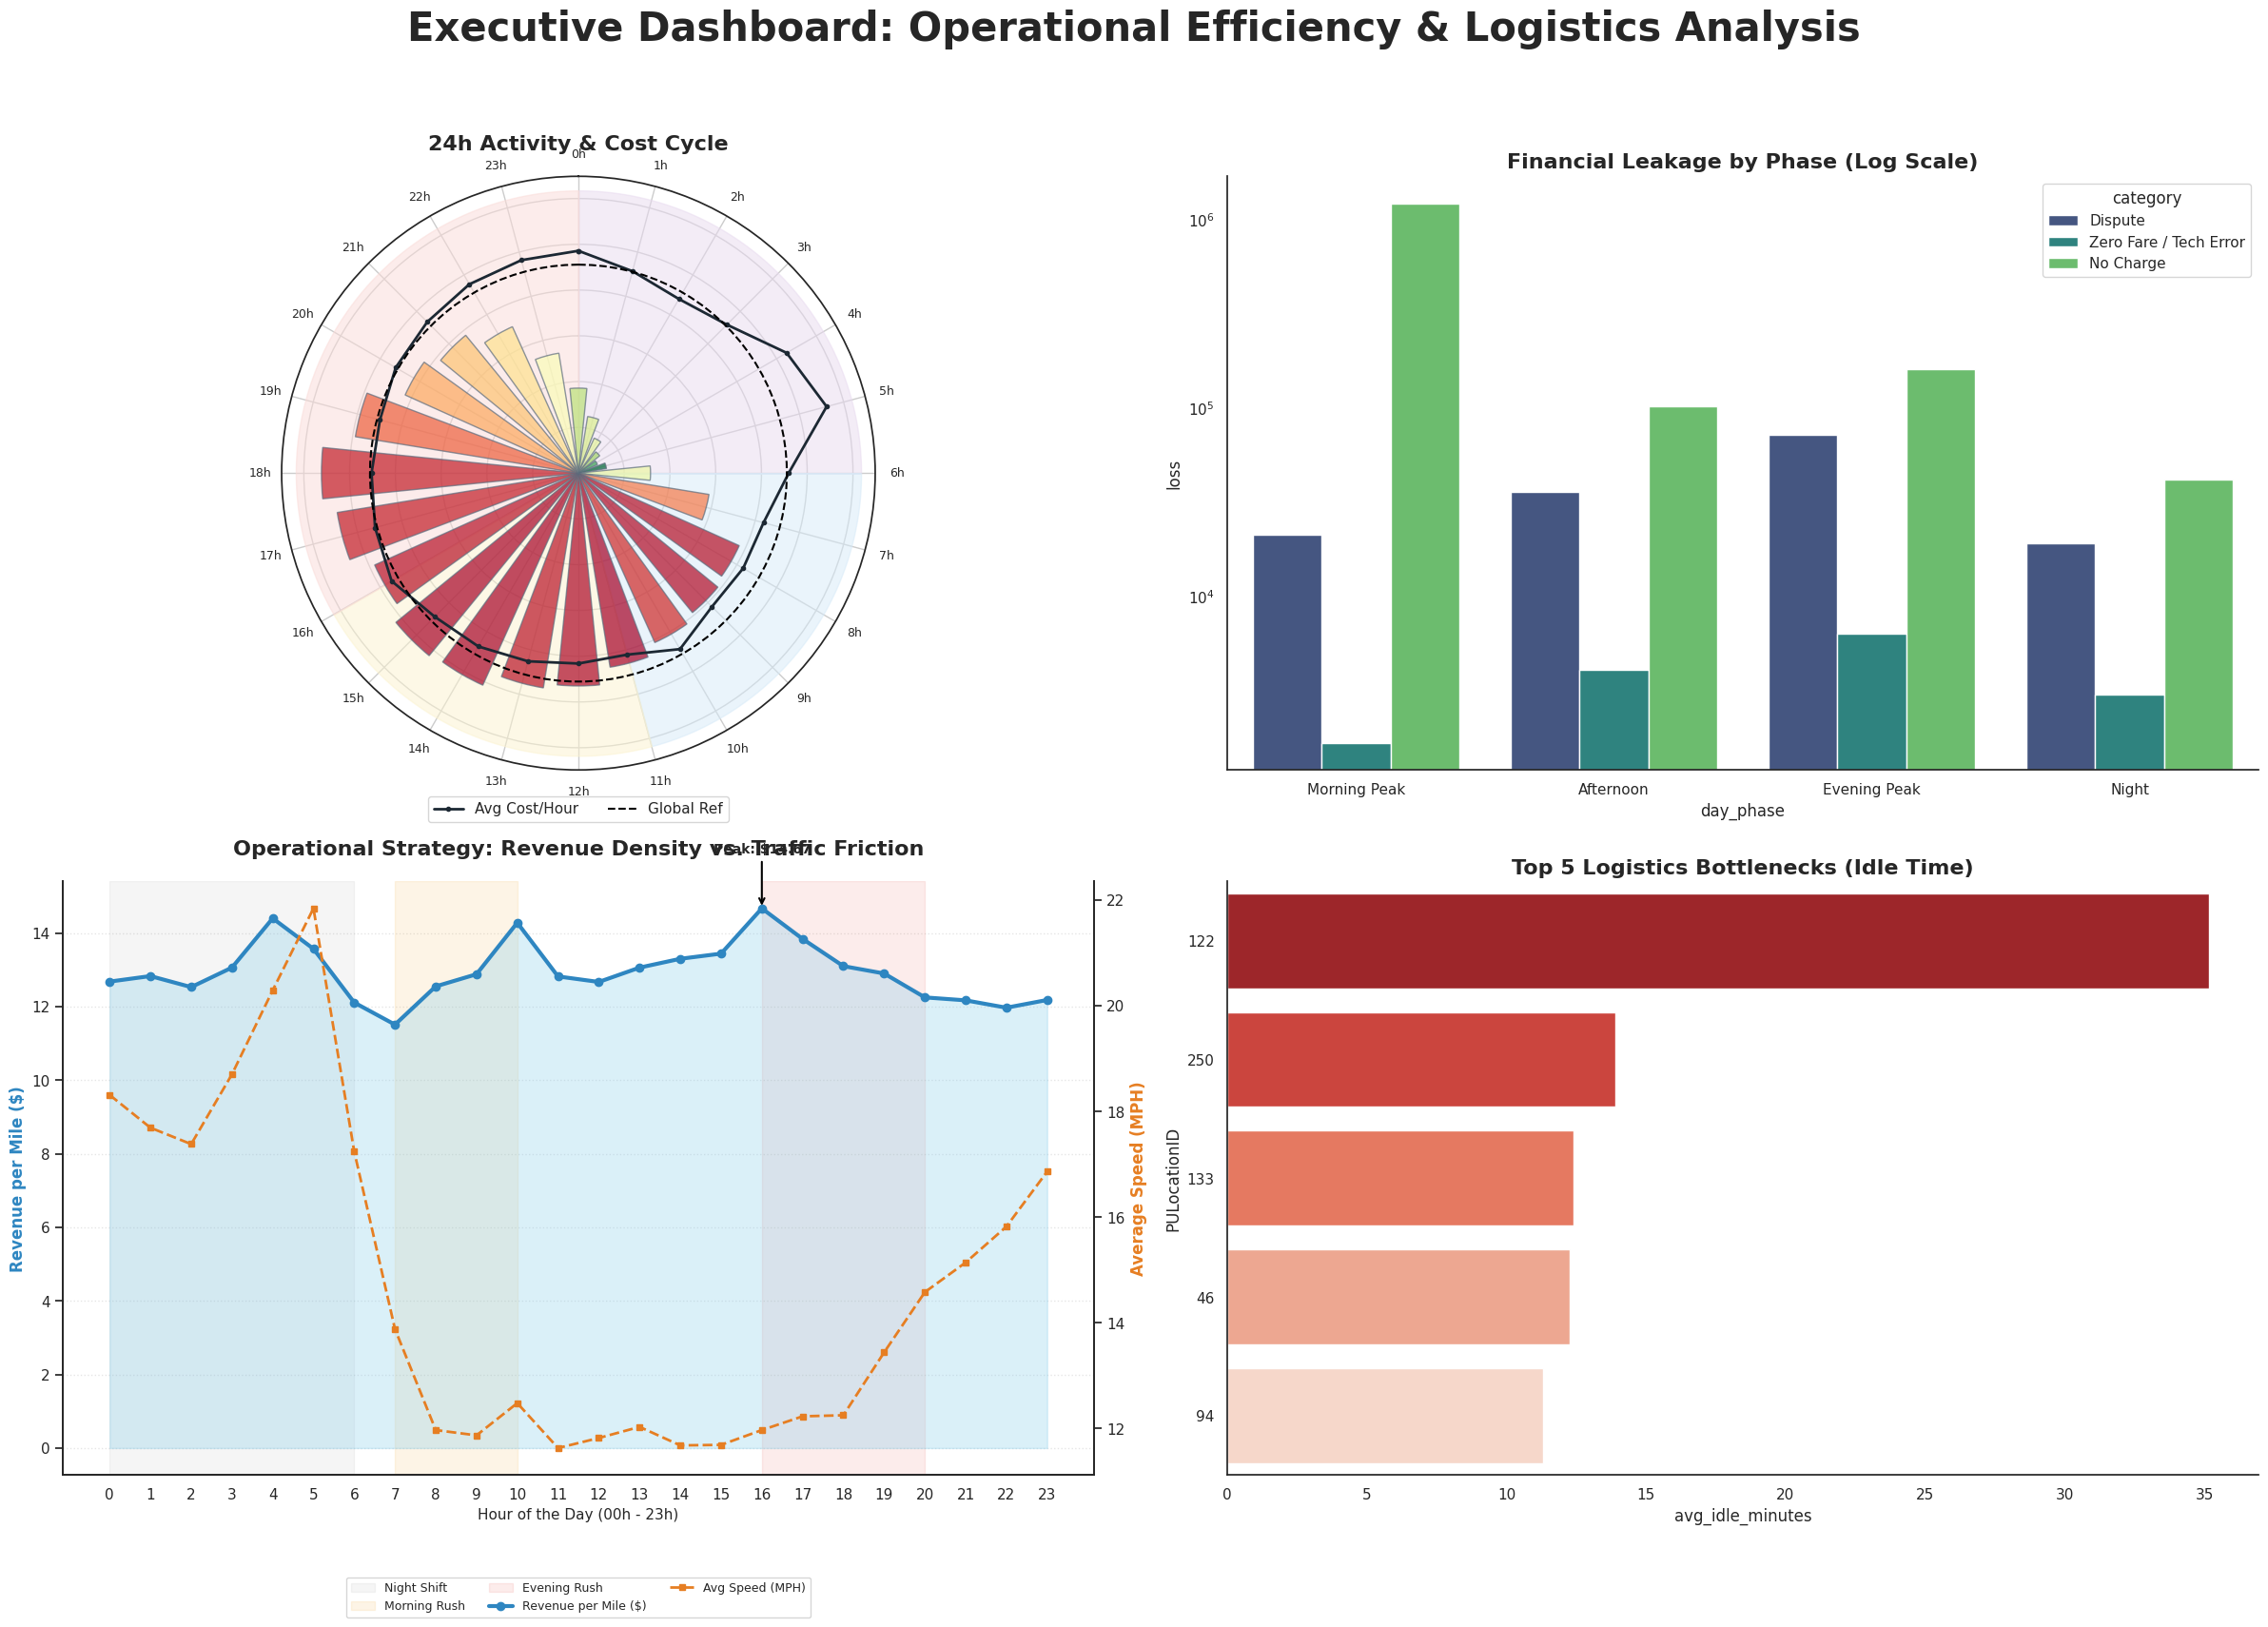

In [182]:
labels = df_agg['hour'].values
counts = df_agg['trip_count'].values
stats_speed = df_agg['avg_speed'].values
stats_total = df_agg['avg_total'].values

angles = np.linspace(0, 2 * np.pi, len(labels), endpoint=False).tolist()
angles_closed = angles + [angles[0]]
stats_total_closed = np.append(stats_total, stats_total[0])

norm = plt.Normalize(stats_speed.min(), stats_speed.max())
colors_map = plt.cm.RdYlGn(norm(stats_speed))

scale_factor = counts.max() / stats_total.max()
cost_scaled = stats_total_closed * scale_factor
reference_value = 18.50
ref_scaled = reference_value * scale_factor

sns.set_theme(style="white")
fig = plt.figure(figsize=(24, 18), facecolor='white')
fig.suptitle("Executive Dashboard: Operational Efficiency & Logistics Analysis",
             fontsize=30, fontweight='bold', y=0.98)

ax1 = plt.subplot(2, 2, 1, projection='polar')
for start, end, color, label in phases:
    ax1.fill_between(np.linspace(hr_to_rad(start), hr_to_rad(end), 100),
                    0, counts.max() * 1.1, color=color, alpha=0.5, zorder=1)
ax1.bar(angles, counts, width=0.2, color=colors_map, alpha=0.7, edgecolor='#5D6D7E', zorder=2)
ax1.plot(angles_closed, cost_scaled, color='#1C2833', linewidth=2, marker='o', markersize=3, label='Avg Cost/Hour')
ax1.plot(np.linspace(0, 2*np.pi, 100), [ref_scaled]*100, color='black', linestyle='--', label='Global Ref')
ax1.set_theta_offset(np.pi / 2)
ax1.set_theta_direction(-1)
ax1.set_xticks(np.linspace(0, 2 * np.pi, 24, endpoint=False))
ax1.set_xticklabels([f"{h}h" for h in range(24)], fontsize=9)
ax1.set_yticklabels([])
ax1.set_title("24h Activity & Cost Cycle", fontsize=16, fontweight='bold', pad=20)
ax1.legend(loc='lower center', bbox_to_anchor=(0.5, -0.1), ncol=3)

ax2 = plt.subplot(2, 2, 2)
sns.barplot(data=pdf_dw, x='day_phase', y='loss', hue='category', palette='viridis', ax=ax2)
ax2.set_yscale('log')
ax2.set_title("Financial Leakage by Phase (Log Scale)", fontsize=16, fontweight='bold')
sns.despine(ax=ax2)

ax3 = plt.subplot(2, 2, 3)
ax3_twin = ax3.twinx()
ax3.axvspan(0, 6, color='gray', alpha=0.08, label='Night Shift')
ax3.axvspan(7, 10, color='#F39C12', alpha=0.1, label='Morning Rush')
ax3.axvspan(16, 20, color='#E74C3C', alpha=0.1, label='Evening Rush')
line1, = ax3.plot(pdf_efficiency['hour'], pdf_efficiency['rev_per_mile'],
                  color='#2E86C1', marker='o', linewidth=3, markersize=6,
                  label='Revenue per Mile ($)')
ax3.fill_between(pdf_efficiency['hour'], pdf_efficiency['rev_per_mile'],
                 color='skyblue', alpha=0.3)

line2, = ax3_twin.plot(pdf_efficiency['hour'], pdf_efficiency['avg_speed_mph'],
                       color='#E67E22', linestyle='--', linewidth=2, marker='s',
                       markersize=5, label='Avg Speed (MPH)')

max_rev_hour = pdf_efficiency.loc[pdf_efficiency['rev_per_mile'].idxmax(), 'hour']
max_rev_val = pdf_efficiency['rev_per_mile'].max()
ax3.annotate(f'Peak: ${max_rev_val:.2f}',
             xy=(max_rev_hour, max_rev_val),
             xytext=(max_rev_hour, max_rev_val + 1.5),
             ha='center',
             arrowprops=dict(arrowstyle='->', lw=1.5, color='black'),
             fontsize=10, fontweight='bold')

ax3.set_title("Operational Strategy: Revenue Density vs. Traffic Friction",
             fontsize=16, fontweight='bold', pad=20)
ax3.set_xlabel("Hour of the Day (00h - 23h)", fontsize=11)
ax3.set_ylabel("Revenue per Mile ($)", color='#2E86C1', fontweight='bold')
ax3_twin.set_ylabel("Average Speed (MPH)", color='#E67E22', fontweight='bold')
ax3.set_xticks(range(0, 24))
ax3.grid(axis='y', linestyle=':', alpha=0.5)
h1, l1 = ax3.get_legend_handles_labels()
h2, l2 = ax3_twin.get_legend_handles_labels()
ax3.legend(h1 + h2, l1 + l2, loc='lower center', bbox_to_anchor=(0.5, -0.25),
           ncol=3, fontsize=9, frameon=True)

ax3.spines['top'].set_visible(False)
ax3_twin.spines['top'].set_visible(False)
ax4 = plt.subplot(2, 2, 4)
sns.barplot(x="avg_idle_minutes", y=pdf_idle_sql["PULocationID"].astype(str),
            data=pdf_idle_sql, palette="Reds_r", ax=ax4, hue=pdf_idle_sql["PULocationID"].astype(str), legend=False)
ax4.set_title("Top 5 Logistics Bottlenecks (Idle Time)", fontsize=16, fontweight='bold')
sns.despine(ax=ax4)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()